Neural Network and Deep Learning

In [1]:
# import sys

# # Prints the exact path to the Python interpreter being used
# print("Executable path:", sys.executable)

# # Prints the Python version
# print("Python version:", sys.version)

In [2]:
!git clone https://github.com/alexeygrigorev/clothing-dataset-small.git

Cloning into 'clothing-dataset-small'...
remote: Enumerating objects: 3839, done.
remote: Counting objects: 100% (400/400), done.
remote: Compressing objects: 100% (400/400), done.
remote: Total 3839 (delta 9), reused 385 (delta 0), pack-reused 3439 (from 1)
Receiving objects: 100% (3839/3839), 100.58 MiB | 18.35 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [4]:
import tensorflow as tf
from tensorflow import keras

In [5]:
from tensorflow.keras.preprocessing.image import load_img

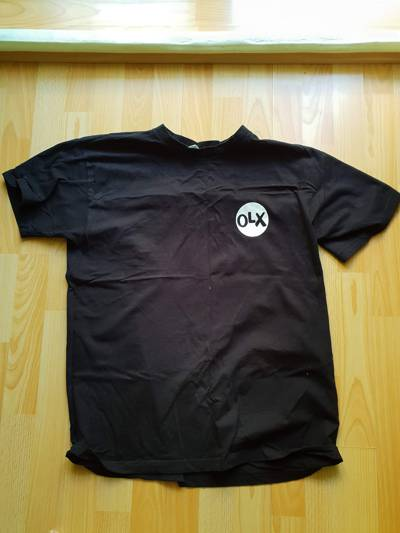

In [6]:
path = './clothing-dataset-small/train/t-shirt'
name = '5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'
fullname = f'{path}/{name}'
load_img(fullname)

In [7]:
img = load_img(fullname, target_size=(299, 299))

In [8]:
x = np.array(img)
x.shape

(299, 299, 3)

Pre-Trained Comnvolutional Neural Networks

In [9]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [10]:
model = Xception(weights='imagenet', input_shape=(299, 299, 3))

91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [11]:
X = np.array([x])

In [12]:
X.shape

(1, 299, 299, 3)

In [13]:
X = preprocess_input(X)

In [14]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 23s 23s/step


In [15]:
decode_predictions(pred)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


[[('n03595614', 'jersey', np.float32(0.68196356)),
  ('n02916936', 'bulletproof_vest', np.float32(0.038139977)),
  ('n04370456', 'sweatshirt', np.float32(0.034324735)),
  ('n03710637', 'maillot', np.float32(0.011354207)),
  ('n04525038', 'velvet', np.float32(0.0018453562))]]

Convolutional Neural Network

Transfer Learning

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(150, 150),
    batch_size=32
)

Found 3068 images belonging to 10 classes.


In [18]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [19]:
X, y = next(train_ds)

In [20]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


In [21]:
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

base_model.trainable = False



inputs = keras.Input(shape=(150, 150, 3))

base = base_model(inputs, training=False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [22]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.CategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [23]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 57s 405ms/step - accuracy: 0.6545 - loss: 1.3166 - val_accuracy: 0.7185 - val_loss: 1.0010
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.8302 - loss: 0.5318 - val_accuracy: 0.7478 - val_loss: 1.0823
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.8729 - loss: 0.3739 - val_accuracy: 0.8006 - val_loss: 0.8922
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.9208 - loss: 0.2172 - val_accuracy: 0.8065 - val_loss: 0.8282
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9430 - loss: 0.1623 - val_accuracy: 0.7742 - val_loss: 0.9781
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.9563 - loss: 0.1205 - val_accuracy: 0.7654 - val_loss: 1.0651
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9456 - loss: 0.1712 - val_accuracy: 0.8123 - val_loss: 0.9609
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9821 - loss: 0.0676 - val_accuracy: 0.8094 

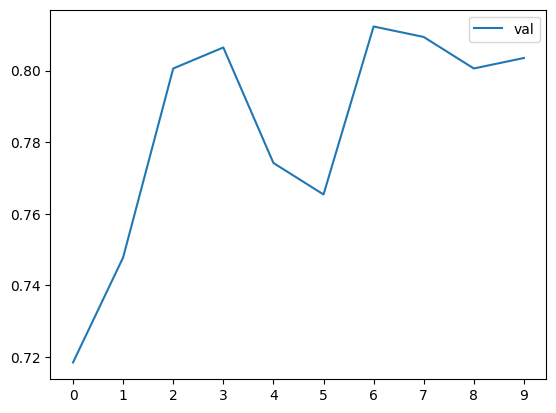

In [24]:
#plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xticks(np.arange(10))
plt.legend()

Adjusting the learning rate

In [25]:
def make_model(learning_rate=0.01):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(10)(vectors)
    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [26]:
scores = {}

for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(lr)

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history

    print()
    print()

0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 202ms/step - accuracy: 0.3175 - loss: 1.9727 - val_accuracy: 0.4985 - val_loss: 1.6281
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.5512 - loss: 1.4056 - val_accuracy: 0.6129 - val_loss: 1.2623
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.6327 - loss: 1.1532 - val_accuracy: 0.6628 - val_loss: 1.0778
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.6698 - loss: 1.0105 - val_accuracy: 0.7097 - val_loss: 0.9655
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.7040 - loss: 0.9163 - val_accuracy: 0.7273 - val_loss: 0.8896
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.7252 - loss: 0.8467 - val_accuracy: 0.7273 - val_loss: 0.8391
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.7422 - loss: 0.7931 - val_accuracy: 0.7449 - val_loss: 0.7952
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.7526 - loss: 0.7502 - val_accuracy: 0

In [27]:
del scores[0.1]
del scores[0.0001]

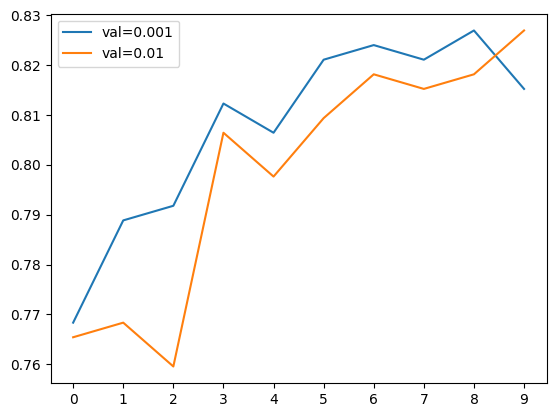

In [28]:
for lr, hist in scores.items():
    #plt.plot(hist['accuracy'], label=('train=%s' % lr))
    plt.plot(hist['val_accuracy'], label=('val=%s' % lr))

plt.xticks(np.arange(10))
plt.legend()

In [29]:
learning_rate = 0.001

Checkpointing

In [33]:
model.save_weights('model_v1.weights.h5')

In [34]:
chechpoint = keras.callbacks.ModelCheckpoint(
    'xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [35]:
learning_rate = 0.001

model = make_model(learning_rate=learning_rate)

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[chechpoint]
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5163 - loss: 1.4754

96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 207ms/step - accuracy: 0.6261 - loss: 1.1187 - val_accuracy: 0.7683 - val_loss: 0.7294
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7683 - loss: 0.6737

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.7819 - loss: 0.6415 - val_accuracy: 0.8035 - val_loss: 0.6231
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8398 - loss: 0.5074

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.8302 - loss: 0.5148 - val_accuracy: 0.8152 - val_loss: 0.5771
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8571 - loss: 0.4343

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.8611 - loss: 0.4290 - val_accuracy: 0.8182 - val_loss: 0.5712
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.8869 - loss: 0.3776 - val_accuracy: 0.8152 - val_loss: 0.5334
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9109 - loss: 0.3243

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9045 - loss: 0.3302 - val_accuracy: 0.8358 - val_loss: 0.5381
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.9162 - loss: 0.2934 - val_accuracy: 0.8182 - val_loss: 0.5298
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.9351 - loss: 0.2604 - val_accuracy: 0.8299 - val_loss: 0.5535
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9407 - loss: 0.2377 - val_accuracy: 0.8182 - val_loss: 0.5524
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9518 - loss: 0.2115 - val_accuracy: 0.8152 - val_loss: 0.5615


Adding more layers

In [36]:
def make_model(learning_rate=0.01, size_inner=100):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)

    outputs = keras.layers.Dense(10)(inner)

    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [37]:
learning_rate = 0.001

scores = {}

for size in [10, 100, 1000]:
    print(size)

    model = make_model(learning_rate=learning_rate, size_inner=size)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[size] = history.history

    print()
    print()


10
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 220ms/step - accuracy: 0.3983 - loss: 1.7198 - val_accuracy: 0.5484 - val_loss: 1.3856
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.6014 - loss: 1.2181 - val_accuracy: 0.6481 - val_loss: 1.0483
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.7285 - loss: 0.8440 - val_accuracy: 0.7243 - val_loss: 0.8307
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.7956 - loss: 0.6348 - val_accuracy: 0.7713 - val_loss: 0.7537
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.8263 - loss: 0.5294 - val_accuracy: 0.7771 - val_loss: 0.6794
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8569 - loss: 0.4537 - val_accuracy: 0.7977 - val_loss: 0.6497
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.8797 - loss: 0.3984 - val_accuracy: 0.7889 - val_loss: 0.6201
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9029 - loss: 0.3433 - val_accuracy: 0.800

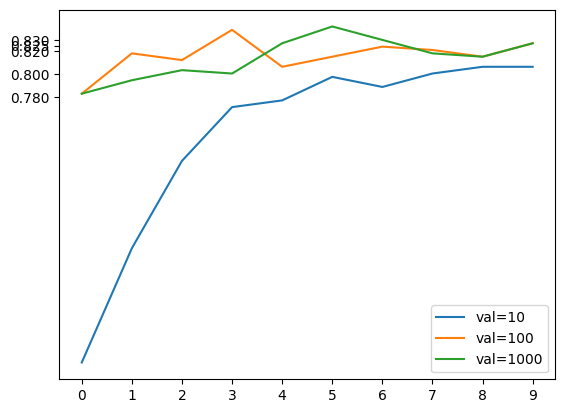

In [38]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % size))

plt.xticks(np.arange(10))
plt.yticks([0.78, 0.80, 0.82, 0.825, 0.83])
plt.legend()

Regularization and dropout

Regularizing by freezing a part of the network  
Adding dropout to our model  
Experimenting with different values  

In [39]:
def make_model(learning_rate=0.01, size_inner=100, droprate=0.5):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [40]:
learning_rate = 0.001
size = 100

scores = {}

for droprate in [0.0, 0.2, 0.5, 0.8]:
    print(droprate)

    model = make_model(
        learning_rate=learning_rate,
        size_inner=size,
        droprate=droprate
    )

    history = model.fit(train_ds, epochs=30, validation_data=val_ds)
    scores[droprate] = history.history

    print()
    print()

0.0
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 214ms/step - accuracy: 0.6636 - loss: 0.9776 - val_accuracy: 0.7918 - val_loss: 0.6447
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.8217 - loss: 0.5216 - val_accuracy: 0.7830 - val_loss: 0.6553
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8752 - loss: 0.3677 - val_accuracy: 0.8094 - val_loss: 0.5594
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9179 - loss: 0.2617 - val_accuracy: 0.8211 - val_loss: 0.5335
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9492 - loss: 0.1802 - val_accuracy: 0.8240 - val_loss: 0.5535
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9756 - loss: 0.1195 - val_accuracy: 0.8270 - val_loss: 0.5382
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.9863 - loss: 0.0853 - val_accuracy: 0.8123 - val_loss: 0.5968
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.9935 - loss: 0.0622 - val_accuracy: 0.81

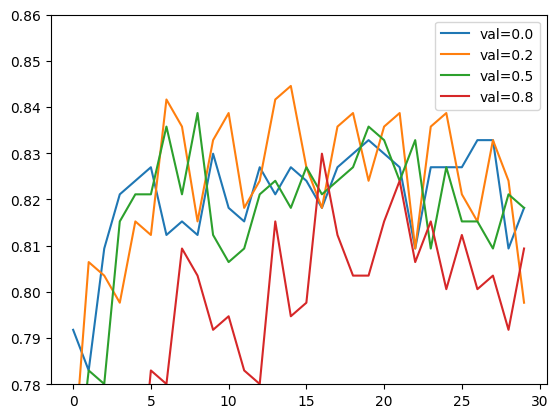

In [41]:
for droprate, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % droprate))

plt.ylim(0.78, 0.86)
plt.legend()

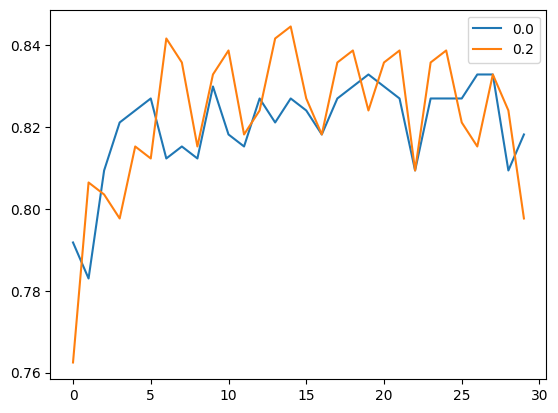

In [42]:
hist = scores[0.0]
plt.plot(hist['val_accuracy'], label=0.0)

hist = scores[0.2]
plt.plot(hist['val_accuracy'], label=0.2)

plt.legend()
#plt.plot(hist['accuracy'], label=('val=%s' % droprate))

Data augmentation

Different data augmentations  
Training a model with augmentations  
How to select data augmentations?  

In [43]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
#     vertical_flip=True,
)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(150, 150),
    batch_size=32
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [44]:
learning_rate = 0.001
size = 100
droprate = 0.2

model = make_model(
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

history = model.fit(train_ds, epochs=50, validation_data=val_ds)

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 223ms/step - accuracy: 0.6470 - loss: 1.0522 - val_accuracy: 0.7889 - val_loss: 0.6641
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.7969 - loss: 0.5791 - val_accuracy: 0.8035 - val_loss: 0.6018
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.8468 - loss: 0.4471 - val_accuracy: 0.7918 - val_loss: 0.5855
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - accuracy: 0.8833 - loss: 0.3501 - val_accuracy: 0.8240 - val_loss: 0.5485
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9123 - loss: 0.2692 - val_accuracy: 0.8065 - val_loss: 0.5704
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9325 - loss: 0.2157 - val_accuracy: 0.8328 - val_loss: 0.5817
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9485 - loss: 0.1732 - val_accuracy: 0.8416 - val_loss: 0.5292
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9619 - loss: 0.1417 - val_accuracy: 0.8123 

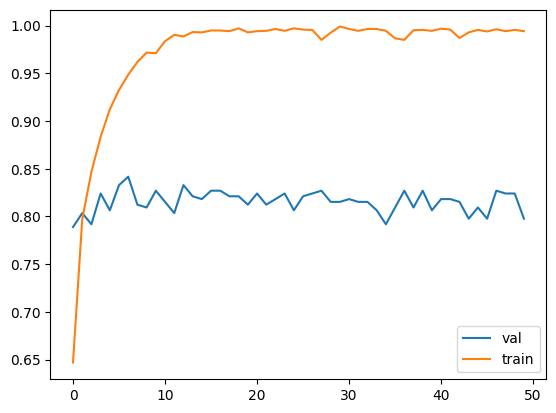

In [45]:
hist = history.history
plt.plot(hist['val_accuracy'], label='val')
plt.plot(hist['accuracy'], label='train')

plt.legend()

 Training a larger model

In [46]:
def make_model(input_size=150, learning_rate=0.01, size_inner=100,
               droprate=0.5):

    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(input_size, input_size, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(input_size, input_size, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [47]:
input_size = 299

In [48]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(input_size, input_size),
    batch_size=32
)


val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(input_size, input_size),
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [49]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v4_1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [50]:
learning_rate = 0.0005
size = 100
droprate = 0.2

model = make_model(
    input_size=input_size,
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

history = model.fit(train_ds, epochs=50, validation_data=val_ds,
                   callbacks=[checkpoint])

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5508 - loss: 1.4380

96/96 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.6855 - loss: 1.0284 - val_accuracy: 0.8035 - val_loss: 0.6063
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.8032 - loss: 0.5906

96/96 ━━━━━━━━━━━━━━━━━━━━ 85s 876ms/step - accuracy: 0.8168 - loss: 0.5562 - val_accuracy: 0.8651 - val_loss: 0.4554
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 82s 856ms/step - accuracy: 0.8478 - loss: 0.4526 - val_accuracy: 0.8651 - val_loss: 0.4203
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 83s 865ms/step - accuracy: 0.8569 - loss: 0.4055 - val_accuracy: 0.8622 - val_loss: 0.4173
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 756ms/step - accuracy: 0.8722 - loss: 0.3532

96/96 ━━━━━━━━━━━━━━━━━━━━ 82s 853ms/step - accuracy: 0.8774 - loss: 0.3513 - val_accuracy: 0.8680 - val_loss: 0.4125
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 770ms/step - accuracy: 0.8745 - loss: 0.3372

96/96 ━━━━━━━━━━━━━━━━━━━━ 82s 853ms/step - accuracy: 0.8823 - loss: 0.3271 - val_accuracy: 0.8827 - val_loss: 0.3746
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 83s 866ms/step - accuracy: 0.8967 - loss: 0.3099 - val_accuracy: 0.8651 - val_loss: 0.3947
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 83s 866ms/step - accuracy: 0.9058 - loss: 0.2795 - val_accuracy: 0.8680 - val_loss: 0.4071
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 780ms/step - accuracy: 0.9175 - loss: 0.2449

96/96 ━━━━━━━━━━━━━━━━━━━━ 84s 876ms/step - accuracy: 0.9084 - loss: 0.2590 - val_accuracy: 0.8856 - val_loss: 0.3738
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 140s 859ms/step - accuracy: 0.9175 - loss: 0.2491 - val_accuracy: 0.8768 - val_loss: 0.3770
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 82s 853ms/step - accuracy: 0.9250 - loss: 0.2289 - val_accuracy: 0.8739 - val_loss: 0.3779
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 82s 854ms/step - accuracy: 0.9231 - loss: 0.2252 - val_accuracy: 0.8651 - val_loss: 0.3660
Epoch 13/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 81s 842ms/step - accuracy: 0.9280 - loss: 0.2108 - val_accuracy: 0.8768 - val_loss: 0.3493
Epoch 14/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 82s 857ms/step - accuracy: 0.9377 - loss: 0.1964 - val_accuracy: 0.8768 - val_loss: 0.3716
Epoch 15/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 81s 835ms/step - accuracy: 0.9384 - loss: 0.1829 - val_accuracy: 0.8827 - val_loss: 0.3985
Epoch 16/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 84s 874ms/step - accuracy: 0.9426 - loss: 0.1773 - val_accurac

96/96 ━━━━━━━━━━━━━━━━━━━━ 82s 856ms/step - accuracy: 0.9495 - loss: 0.1550 - val_accuracy: 0.8944 - val_loss: 0.3961
Epoch 20/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 770ms/step - accuracy: 0.9522 - loss: 0.1377

96/96 ━━━━━━━━━━━━━━━━━━━━ 83s 863ms/step - accuracy: 0.9478 - loss: 0.1498 - val_accuracy: 0.9003 - val_loss: 0.3433
Epoch 21/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 82s 853ms/step - accuracy: 0.9547 - loss: 0.1383 - val_accuracy: 0.8827 - val_loss: 0.3969
Epoch 22/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 84s 871ms/step - accuracy: 0.9563 - loss: 0.1389 - val_accuracy: 0.8827 - val_loss: 0.3670
Epoch 23/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 81s 842ms/step - accuracy: 0.9560 - loss: 0.1332 - val_accuracy: 0.8974 - val_loss: 0.3443
Epoch 24/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 81s 842ms/step - accuracy: 0.9593 - loss: 0.1265 - val_accuracy: 0.8974 - val_loss: 0.3766
Epoch 25/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 81s 840ms/step - accuracy: 0.9632 - loss: 0.1219 - val_accuracy: 0.8680 - val_loss: 0.3639
Epoch 26/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 80s 829ms/step - accuracy: 0.9668 - loss: 0.1062 - val_accuracy: 0.8768 - val_loss: 0.4077
Epoch 27/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 80s 829ms/step - accuracy: 0.9641 - loss: 0.1141 - val_accuracy

Using the model

In [51]:
import tensorflow as tf
from tensorflow import keras

In [52]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img

from tensorflow.keras.applications.xception import preprocess_input

In [53]:
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    './clothing-dataset-small/test',
    target_size=(299, 299),
    batch_size=32,
    shuffle=False
)

Found 372 images belonging to 10 classes.


In [54]:
model = keras.models.load_model('xception_v4_1_20_0.900.h5')

In [55]:
model.evaluate(test_ds)

12/12 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.9059 - loss: 0.2582


[0.2582458257675171, 0.9059139490127563]

In [56]:
path = 'clothing-dataset-small/test/pants/c8d21106-bbdb-4e8d-83e4-bf3d14e54c16.jpg'

In [57]:
img = load_img(path, target_size=(299, 299))

In [58]:
import numpy as np

In [59]:
x = np.array(img)
X = np.array([x])
X.shape

(1, 299, 299, 3)

In [60]:
X = preprocess_input(X)

In [61]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


In [62]:
classes = [
    'dress',
    'hat',
    'longsleeve',
    'outwear',
    'pants',
    'shirt',
    'shoes',
    'shorts',
    'skirt',
    't-shirt'
]

In [63]:
dict(zip(classes, pred[0]))

{'dress': np.float32(-2.7770154),
 'hat': np.float32(-8.065406),
 'longsleeve': np.float32(-2.372666),
 'outwear': np.float32(-3.71527),
 'pants': np.float32(10.055162),
 'shirt': np.float32(-3.3588264),
 'shoes': np.float32(-4.7014074),
 'shorts': np.float32(4.186758),
 'skirt': np.float32(-4.4164557),
 't-shirt': np.float32(-3.7886555)}

In [64]:
from google.colab import files

# Replace with the actual path and name of your model file
files.download('/content/xception_v4_1_20_0.900.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>